# 09 — Missing-Data Robustness

**How do the models cope when feature values go missing?**

In production this project sidesteps the question: `build_features` ends with `dropna()`, so the
feature matrix the models train and predict on has **no NaNs**. But real pipelines spring leaks —
a missing MISO daily file, a sensor outage, a lag that isn't available yet. This notebook
stress-tests how each model behaves when gaps appear in the **2024 test set**, and shows how to
make the fragile models gap-safe.

**What we'll establish (verified, not asserted):**
1. **Tree models don't crash on NaN** — XGBoost and scikit-learn's trees / Random Forest / Bagging
   all have native missing-value support (sklearn since 1.4), so they predict through gaps with no
   imputer.
2. **Linear Regression and the DNN crash** on any NaN input — they need imputation (a `SimpleImputer`
   step makes them run).
3. **But "doesn't crash" ≠ "robust".** Once everyone is running, how much accuracy each model loses
   as the gap rate grows differs *enormously* — with a genuinely counterintuitive result about which
   model copes **worst**. (Spoiler: it's not the one you'd guess.)

Same data, features, and 2022→2023 / 2024 split as notebooks 03/07/08. We train on **clean** data
(the realistic case) and inject missingness only at inference.

In [1]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/features/feature_matrix_v2.csv', parse_dates=['Time'], index_col='Time')
FEATURES = [c for c in df.columns if c not in ['LMP', 'Energy', 'Congestion', 'Loss']]
X, y = df[FEATURES], df['LMP']

train_start, split_date = '2022-01-01', '2024-01-01'
X_train = X[(X.index >= train_start) & (X.index < split_date)]
X_test  = X[X.index >= split_date]
y_train = y[(y.index >= train_start) & (y.index < split_date)]
y_test  = y[y.index >= split_date]

print(f"Train rows: {len(X_train):,}  (NaNs: {int(X_train.isna().sum().sum())})")
print(f"Test  rows: {len(X_test):,}  (NaNs: {int(X_test.isna().sum().sum())})")

Train rows: 17,520  (NaNs: 0)
Test  rows: 8,784  (NaNs: 0)


## A helper to punch holes in the data

`inject_missing` masks each cell of the feature matrix independently with probability `frac`
(missing-completely-at-random). We only ever apply it to the **test** set — training stays clean.

In [3]:
def inject_missing(X, frac, seed=0):
    """Return a copy of X with ~frac of cells set to NaN (MCAR)."""
    if frac <= 0:
        return X.copy()
    rng  = np.random.default_rng(seed)
    mask = pd.DataFrame(rng.random(X.shape) < frac, index=X.index, columns=X.columns)
    return X.mask(mask)

# quick sanity check
_demo = inject_missing(X_test, 0.05, seed=1)
print(f"At 5% cell-missing: {int(_demo.isna().sum().sum()):,} NaN cells, "
      f"{int(_demo.isna().any(axis=1).sum()):,} of {len(_demo):,} rows have >=1 NaN")

At 5% cell-missing: 14,438 NaN cells, 7,178 of 8,784 rows have >=1 NaN


## Train the models on clean data

Tree models train on raw features. For Linear and the DNN we build two variants: a **naive** one
(scaler + model, no imputer) to show the failure, and a **gap-safe** one with a `SimpleImputer`
in front.

In [4]:
# Tree models -- native NaN support, no imputer needed
bag = BaggingRegressor(n_estimators=100, max_samples=0.8, max_features=0.8,
                       n_jobs=-1, random_state=42).fit(X_train, y_train)
rf  = RandomForestRegressor(n_estimators=300, max_depth=16, min_samples_leaf=5,
                            max_features='sqrt', n_jobs=-1, random_state=42).fit(X_train, y_train)
xgb_model = xgb.XGBRegressor(); xgb_model.load_model('models/xgb_lmp_v1.json')

# Naive (no imputer) -- only used to demonstrate the crash. Small/fast configs.
lin_naive = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
dnn_naive = make_pipeline(StandardScaler(),
                          MLPRegressor(hidden_layer_sizes=(64,), max_iter=10,
                                       random_state=0)).fit(X_train, y_train)

# Gap-safe -- SimpleImputer(median) learned on the clean training set, then scale + model
lin_pipe = make_pipeline(SimpleImputer(strategy='median'),
                         StandardScaler(),
                         LinearRegression()).fit(X_train, y_train)
dnn_pipe = make_pipeline(SimpleImputer(strategy='median'),
                         StandardScaler(),
                         MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu',
                                      solver='adam', alpha=1e-3, batch_size=256,
                                      learning_rate_init=1e-3, max_iter=300, early_stopping=True,
                                      n_iter_no_change=15, validation_fraction=0.1,
                                      random_state=42)).fit(X_train, y_train)
print("All models trained.")

All models trained.


## Part A — what happens with NO missing-data handling

Inject 5% missing into the test set and ask each model to predict. The tree models shrug;
Linear and the DNN raise `ValueError`.

In [5]:
X_test_5 = inject_missing(X_test, 0.05, seed=1)

candidates = {
    'Linear (no imputer)':     lin_naive,
    'DNN (no imputer)':        dnn_naive,
    'Bagging (native)':        bag,
    'Random Forest (native)':  rf,
    'XGBoost (native)':        xgb_model,
}

for name, est in candidates.items():
    try:
        p = est.predict(X_test_5)
        print(f"{name:24s}: OK     MAE ${mean_absolute_error(y_test, p):5.2f}")
    except Exception as e:
        print(f"{name:24s}: CRASH  {type(e).__name__}: {str(e).splitlines()[0][:55]}")

Linear (no imputer)     : CRASH  ValueError: Input X contains NaN.
DNN (no imputer)        : CRASH  ValueError: Input X contains NaN.


Bagging (native)        : OK     MAE $ 6.01
Random Forest (native)  : OK     MAE $ 6.10
XGBoost (native)        : OK     MAE $10.44


## Part B — the imputer fix + degradation curves

Now use the gap-safe Linear/DNN pipelines and sweep the missing rate from 0% to 40%. Every model
runs; we track how MAE on the 2024 holdout degrades.

In [6]:
rates = [0.0, 0.01, 0.05, 0.10, 0.20, 0.40]
curve_models = {
    'XGBoost (native)':       xgb_model,
    'Random Forest (native)': rf,
    'Bagging (native)':       bag,
    'Linear (+imputer)':      lin_pipe,
    'DNN (+imputer)':         dnn_pipe,
}

rows = []
for name, est in curve_models.items():
    for r in rates:
        Xm  = inject_missing(X_test, r, seed=int(r * 1000) + 7)
        mae = mean_absolute_error(y_test, est.predict(Xm))
        rows.append({'Model': name, 'missing_rate': r, 'MAE': mae})

curve = pd.DataFrame(rows)
table = curve.pivot(index='missing_rate', columns='Model', values='MAE').round(2)
table.index = [f"{int(r*100)}%" for r in table.index]
print("MAE ($/MWh) vs % of test feature values missing:")
print(table.to_string())
table

MAE ($/MWh) vs % of test feature values missing:
Model  Bagging (native)  DNN (+imputer)  Linear (+imputer)  Random Forest (native)  XGBoost (native)
0%                 5.96            7.42               6.00                    6.06              5.88
1%                 5.98            7.55               6.13                    6.07              6.64
5%                 6.07            8.23               6.64                    6.11              9.95
10%                6.14            8.91               7.27                    6.15             14.68
20%                6.35           10.09               8.45                    6.26             23.93
40%                6.92           11.59              10.47                    6.62             44.00


Model,Bagging (native),DNN (+imputer),Linear (+imputer),Random Forest (native),XGBoost (native)
0%,5.96,7.42,6.00,6.06,5.88
1%,5.98,7.55,6.13,6.07,6.64
5%,6.07,8.23,6.64,6.11,9.95
10%,6.14,8.91,7.27,6.15,14.68
20%,6.35,10.09,8.45,6.26,23.93
40%,6.92,11.59,10.47,6.62,44.00


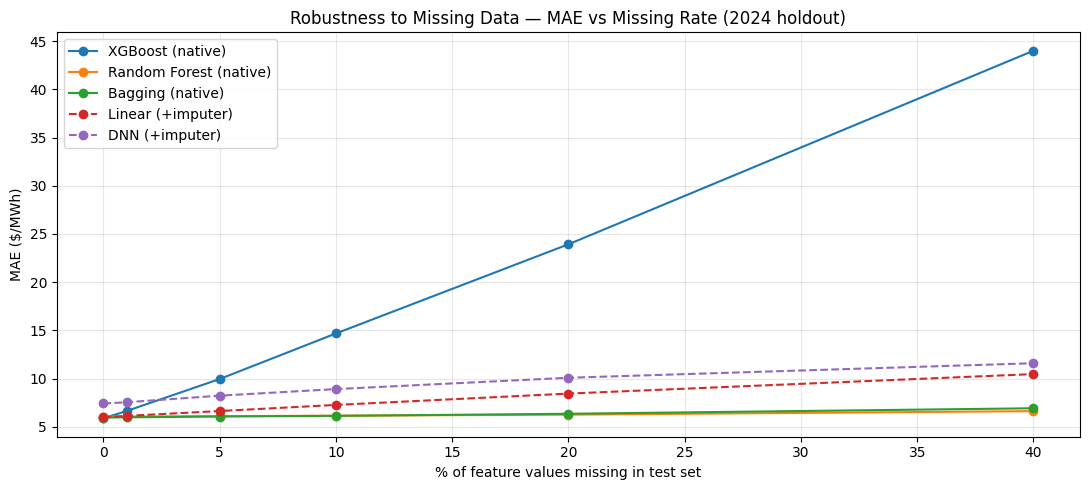

In [7]:
# --- Degradation curves ---
fig, ax = plt.subplots(figsize=(11, 5))
for name in curve_models:
    sub = curve[curve.Model == name]
    style = '--' if '+imputer' in name else '-'
    ax.plot(sub['missing_rate'] * 100, sub['MAE'], marker='o', linestyle=style, label=name)
ax.set_xlabel('% of feature values missing in test set')
ax.set_ylabel('MAE ($/MWh)')
ax.set_title('Robustness to Missing Data — MAE vs Missing Rate (2024 holdout)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/missing_data_robustness.png', dpi=150)
plt.show()

In [8]:
curve.round(4).to_csv('results/missing_data_robustness.csv', index=False)
print('Saved results/missing_data_robustness.csv')

Saved results/missing_data_robustness.csv


## Takeaways

**MAE ($/MWh) as test features go missing:**

| Missing | Random Forest | Bagging | Linear (+imp) | DNN (+imp) | XGBoost |
|---|---|---|---|---|---|
| 0% | 6.06 | 5.96 | 6.00 | 7.42 | **5.88** |
| 5% | 6.11 | 6.07 | 6.64 | 8.23 | 9.95 |
| 10% | 6.15 | 6.14 | 7.27 | 8.91 | 14.68 |
| 20% | 6.26 | 6.35 | 8.45 | 10.09 | 23.93 |
| 40% | **6.62** | 6.92 | 10.47 | 11.59 | **44.00** |

**1. Crash vs. survive.** With *no* handling, Linear Regression and the DNN raise `ValueError: Input X contains NaN` on the very first gap — they can't run at all. The three tree models predict through gaps natively. A one-line `SimpleImputer(strategy='median')` in front of LR/DNN makes them run.

**2. The counterintuitive headline — XGBoost is the *least* robust here.** Despite being the champion and having "native" missing-value support, XGBoost degrades the **worst**: from $5.88 (best with no gaps) to **$44.00** at 40% missing — a 7.5× blow-up. Meanwhile **Random Forest and Bagging barely move** ($6.06 → $6.62 and $5.96 → $6.92). This flips the usual "XGBoost handles missing data best" intuition on its head.

**3. Why — "native support" depends on *when* the missingness appears.**
- **scikit-learn trees** (RF/Bagging): a node trained without missing values sends a missing test sample to the **child with more training samples** — a safe majority default. So clean-trained forests barely notice inference-time gaps.
- **XGBoost**: every split stores a single learned **default direction** for missing values. Trained on *complete* data, it never saw a missing example, so those defaults are essentially uninformed — and at inference every gap is shoved down one fixed branch, which compounds fast as the gap rate rises.
- The lesson: **XGBoost's missing-value handling is meant to be learned from training-time missingness.** Give it clean training and it generalizes poorly to gaps it sees only at prediction time.

**4. Imputed LR/DNN degrade gracefully but modestly** — median fill is a stable, flat guess, so error rises steadily rather than exploding (LR $6.00 → $10.47; DNN $7.42 → $11.59).

**Practical guidance**
- This repo's `dropna()` design means **none of this bites in production today** — the models never see NaN.
- If inference-time gaps become possible: **Random Forest / Bagging are dramatically the safest** out of the box; or put a `SimpleImputer` in front of *any* model (including XGBoost) for predictable behavior.
- To keep **XGBoost** robust, train it **with representative missingness** so it learns useful default directions — don't rely on clean-trained defaults.
- Caveat: this is **MCAR** (missing-completely-at-random). Structural missingness (e.g., a lag genuinely unknown at the forecast horizon) is a design problem an imputer only papers over.

**Artifacts written:** `results/missing_data_robustness.csv`, `results/missing_data_robustness.png`.